<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/subseaequipment/subseaequipment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Subsea production equipment and system screening with NeqSim

This tutorial introduces the functional chain from two subsea wells to a host inlet separator. It
uses an entirely synthetic wet gas-condensate case and current NeqSim APIs.

## Learning objectives

After completing the notebook, you should be able to:

- map subsea trees, production chokes, a manifold, flowline, riser, and host separator to a
  composable NeqSim flowsheet;
- select a thermodynamic model and define explicit engineering units;
- inspect choke energy closure, pipeline pressure and temperature profiles, liquid holdup, and
  separator phase splits;
- verify mass, component, and enthalpy balances;
- screen external seawater pressure and sensitivities to choke pressure, heat transfer, and rate;
- identify where a screening model must be replaced by detailed flow-assurance, mechanical, or
  dynamic analysis.

In [1]:
import importlib.metadata
import subprocess
import sys


try:
    neqsim_version = importlib.metadata.version("neqsim")
except importlib.metadata.PackageNotFoundError:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ],
        check=True,
    )
    neqsim_version = importlib.metadata.version("neqsim")

java_runtime = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
).stderr.splitlines()[0]

print(f"NeqSim package: {neqsim_version}")
print(f"Python runtime: {sys.version.split()[0]}")
print(f"Java runtime: {java_runtime}")

NeqSim package: 3.16.0
Python runtime: 3.12.13
Java runtime: openjdk version "17.0.19" 2026-04-21


## Engineering context and scope

A subsea production system must transport an unprocessed, pressure-dependent multiphase fluid
from wells to a receiving facility. The equipment has different roles:

1. each **subsea tree** provides isolation and a production choke;
2. the **manifold** combines well streams at a common pressure;
3. the **flowline and riser** determine hydraulic and thermal arrival conditions;
4. the **host inlet separator** divides gas, hydrocarbon liquid, and water.

This is a steady-state screening model. It does not certify tree, valve, pipe-wall, connector,
umbilical, control-system, slug-catcher, or separator design. The neighboring catalog notebooks
cover more detailed subsea process simulation and multiphase-flow studies.

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from neqsim import jneqsim
from neqsim.process import (
    beggs_brill_pipe,
    clearProcess,
    mixer,
    runProcess,
    separator3phase,
    stream,
    valve,
)
from neqsim.thermo import TPflash, fluid


plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

## Assumptions, units, and model choices

- Pressure is absolute and reported in bara; temperature is in degrees Celsius.
- Flow is mass flow in kg/h; composition is on a molar basis and normalized explicitly.
- The synthetic wells contain water and heavier hydrocarbons, so `cpa-srk` is used. CPA adds
  association physics for water while retaining a cubic hydrocarbon equation of state.
- Mixing rule 10 is the database-backed CPA mixing rule used by this example.
- Both liquid-liquid and vapor-liquid checks are enabled.
- `ThrottlingValve` represents each production choke because NeqSim has no separate `ChokeValve`
  class.
- `PipeBeggsAndBrills` provides a steady empirical pressure-drop and liquid-holdup screen.
- Seawater temperature is fixed at 4°C and the overall heat-transfer coefficient is 3 W/(m² K).

The inputs are deterministic and synthetic; they are not field, vendor, or proprietary data.

In [3]:
COMPONENTS = [
    "nitrogen",
    "CO2",
    "methane",
    "ethane",
    "propane",
    "i-butane",
    "n-butane",
    "i-pentane",
    "n-pentane",
    "n-hexane",
    "n-heptane",
    "water",
]

WELL_SPECIFICATIONS = [
    {
        "name": "Well A",
        "pressure_bara": 132.0,
        "temperature_c": 58.0,
        "flow_kg_h": 11000.0,
        "composition": [
            0.010,
            0.020,
            0.700,
            0.080,
            0.060,
            0.015,
            0.025,
            0.010,
            0.010,
            0.025,
            0.035,
            0.010,
        ],
    },
    {
        "name": "Well B",
        "pressure_bara": 126.0,
        "temperature_c": 52.0,
        "flow_kg_h": 9000.0,
        "composition": [
            0.010,
            0.025,
            0.620,
            0.090,
            0.075,
            0.020,
            0.035,
            0.015,
            0.015,
            0.035,
            0.040,
            0.020,
        ],
    },
]

CASE = {
    "tree_choke_pressure_bara": 100.0,
    "route_length_m": 18000.0,
    "inside_diameter_m": 0.24,
    "net_elevation_m": 350.0,
    "maximum_water_depth_m": 350.0,
    "roughness_m": 4.5e-5,
    "heat_transfer_w_per_m2_k": 3.0,
    "seawater_temperature_c": 4.0,
    "separator_minimum_pressure_bara": 75.0,
}

input_table = pd.DataFrame(WELL_SPECIFICATIONS).drop(columns="composition")
display(input_table)
display(pd.Series(CASE, name="value").to_frame())

,name,pressure_bara,temperature_c,flow_kg_h
0,Well A,132.0,58.0,11000.0
1,Well B,126.0,52.0,9000.0


,value
tree_choke_pressure_bara,100.000000
route_length_m,18000.000000
inside_diameter_m,0.240000
net_elevation_m,350.000000
maximum_water_depth_m,350.000000
roughness_m,0.000045
heat_transfer_w_per_m2_k,3.000000
seawater_temperature_c,4.000000
separator_minimum_pressure_bara,75.000000


## Fluid construction and equilibrium initialization

A temperature-pressure flash minimizes the Gibbs energy at fixed overall composition,
temperature, and pressure. The phase fractions satisfy:

$$
\sum_{\alpha} \beta_{\alpha} = 1
$$

Here $\beta_{\alpha}$ is the molar fraction of phase $\alpha$. The calculation is performed for
each well before equipment is connected, which exposes invalid compositions or phase states early.

In [4]:
def normalized_composition(specification):
    composition = np.asarray(specification["composition"], dtype=float)
    normalized = composition / composition.sum()
    assert math.isclose(float(normalized.sum()), 1.0, abs_tol=1.0e-12)
    return normalized


def build_well_fluid(specification, rate_factor=1.0):
    system = fluid("cpa-srk")
    composition = normalized_composition(specification)

    for component, mole_fraction in zip(COMPONENTS, composition):
        system.addComponent(component, float(mole_fraction))

    system.setMixingRule(10)
    system.setMultiPhaseCheck(True)
    system.setPressure(specification["pressure_bara"], "bara")
    system.setTemperature(specification["temperature_c"], "C")
    system.setTotalFlowRate(
        specification["flow_kg_h"] * rate_factor,
        "kg/hr",
    )
    TPflash(system)
    system.initProperties()
    return system

## Well-stream diagnostics

The two streams intentionally differ in pressure, temperature, rate, water content, and richness.
The pre-choke phase count is diagnostic rather than a design target: phase appearance can change
after isenthalpic letdown and cooling. The molar composition table also makes the normalization
basis auditable.

In [5]:
well_fluids = [
    build_well_fluid(specification)
    for specification in WELL_SPECIFICATIONS
]

well_rows = []
composition_rows = []

for specification, system in zip(WELL_SPECIFICATIONS, well_fluids):
    well_rows.append(
        {
            "well": specification["name"],
            "pressure [bara]": system.getPressure("bara"),
            "temperature [°C]": system.getTemperature("C"),
            "mass flow [kg/h]": system.getFlowRate("kg/hr"),
            "phases [-]": system.getNumberOfPhases(),
            "density [kg/m³]": system.getDensity("kg/m3"),
        }
    )

    normalized = normalized_composition(specification)
    for component, mole_fraction in zip(COMPONENTS, normalized):
        composition_rows.append(
            {
                "well": specification["name"],
                "component": component,
                "mole fraction [-]": mole_fraction,
            }
        )

well_table = pd.DataFrame(well_rows).set_index("well")
composition_table = pd.DataFrame(composition_rows).pivot(
    index="component",
    columns="well",
    values="mole fraction [-]",
)
display(well_table.round(6))
display(composition_table.round(6))

,pressure [bara],temperature [°C],mass flow [kg/h],phases [-],density [kg/m³]
well,,,,,
Well A,132.0,58.0,11000.0,3,183.878357
Well B,126.0,52.0,9000.0,3,223.614696


well,Well A,Well B
component,,
CO2,0.020,0.025
ethane,0.080,0.090
i-butane,0.015,0.020
i-pentane,0.010,0.015
methane,0.700,0.620
n-butane,0.025,0.035
n-heptane,0.035,0.040
n-hexane,0.025,0.035
n-pentane,0.010,0.015


## Equipment model and API choices

The model keeps named streams and equipment so it can be extended into a larger `ProcessSystem`.
The two valves impose a common manifold pressure. Mixing conserves mass and enthalpy:

$$
\dot{m}_{\mathrm{mix}} = \sum_i \dot{m}_i
$$

$$
H_{\mathrm{mix}} = \sum_i H_i
$$

An explicit PH flash is applied to the manifold outlet before the downstream units run. This makes
the balance target visible and gives deterministic behavior across NeqSim versions.

In [6]:
def simulate_subsea_system(
    rate_factor=1.0,
    choke_pressure_bara=CASE["tree_choke_pressure_bara"],
    heat_transfer_w_per_m2_k=CASE["heat_transfer_w_per_m2_k"],
):
    clearProcess()
    feeds = []
    production_chokes = []

    for specification in WELL_SPECIFICATIONS:
        feed = stream(
            specification["name"],
            build_well_fluid(specification, rate_factor),
        )
        production_choke = valve(
            f"{specification['name']} production choke",
            feed,
            p=choke_pressure_bara,
        )
        feeds.append(feed)
        production_chokes.append(production_choke)

    production_manifold = mixer("Subsea production manifold")
    for production_choke in production_chokes:
        production_manifold.addStream(production_choke.getOutletStream())

    pipeline = beggs_brill_pipe(
        "Flowline and riser",
        production_manifold.getOutletStream(),
        length=CASE["route_length_m"],
        diameter=CASE["inside_diameter_m"],
        elevation=CASE["net_elevation_m"],
        roughness=CASE["roughness_m"],
    )
    pipeline.setNumberOfIncrements(24)
    pipeline.setHeatTransferCoefficient(heat_transfer_w_per_m2_k)
    pipeline.setAmbientTemperature(CASE["seawater_temperature_c"] + 273.15)

    inlet_separator = separator3phase(
        "Host inlet separator",
        pipeline.getOutletStream(),
    )
    runProcess()

    inlet_enthalpy_j = sum(
        production_choke.getOutletStream().getFluid().getEnthalpy()
        for production_choke in production_chokes
    )
    mixed_fluid = production_manifold.getOutletStream().getFluid()
    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(
        mixed_fluid
    )
    operations.PHflash(inlet_enthalpy_j)
    mixed_fluid.initProperties()
    pipeline.run()
    inlet_separator.run()

    return {
        "feeds": feeds,
        "chokes": production_chokes,
        "manifold": production_manifold,
        "pipeline": pipeline,
        "separator": inlet_separator,
    }

## Reproducible base case

Both trees choke to 100 bara before the streams mix. The 18 km route has a 0.24 m internal
diameter, a net 350 m rise, and 24 calculation increments. The base-case output reports every
main process boundary so pressure, temperature, phase count, and mass flow can be followed from
wellhead to separator.

In [7]:
base_case = simulate_subsea_system()

named_streams = {
    "Well A": base_case["feeds"][0],
    "Well B": base_case["feeds"][1],
    "Well A after choke": base_case["chokes"][0].getOutletStream(),
    "Well B after choke": base_case["chokes"][1].getOutletStream(),
    "Manifold outlet": base_case["manifold"].getOutletStream(),
    "Host arrival": base_case["pipeline"].getOutletStream(),
}

stream_rows = []
for name, stream_object in named_streams.items():
    stream_rows.append(
        {
            "location": name,
            "pressure [bara]": stream_object.getPressure("bara"),
            "temperature [°C]": stream_object.getTemperature("C"),
            "mass flow [kg/h]": stream_object.getFlowRate("kg/hr"),
            "phases [-]": stream_object.getFluid().getNumberOfPhases(),
        }
    )

stream_table = pd.DataFrame(stream_rows).set_index("location")
display(stream_table.round(6))

,pressure [bara],temperature [°C],mass flow [kg/h],phases [-]
location,,,,
Well A,132.000000,58.000000,11000.0,3
Well B,126.000000,52.000000,9000.0,3
Well A after choke,100.000000,51.749829,11000.0,3
Well B after choke,100.000000,47.139060,9000.0,3
Manifold outlet,100.000000,49.559651,20000.0,3
Host arrival,89.569058,17.875162,20000.0,3


## Tree-choke and manifold energy diagnostics

A throttling valve is modeled as adiabatic with negligible kinetic and potential-energy change:

$$
h_{\mathrm{out}} = h_{\mathrm{in}}
$$

Specific enthalpy is checked in J/kg for each choke. The manifold check uses total stream enthalpy
in joules. Small residuals arise from numerical flash tolerances, not an external heat duty.

In [8]:
energy_rows = []

for feed, production_choke in zip(
    base_case["feeds"],
    base_case["chokes"],
):
    inlet_enthalpy_j_per_kg = feed.getFluid().getEnthalpy("J/kg")
    outlet_enthalpy_j_per_kg = (
        production_choke.getOutletStream().getFluid().getEnthalpy("J/kg")
    )
    energy_rows.append(
        {
            "equipment": str(production_choke.getName()),
            "inlet h [J/kg]": inlet_enthalpy_j_per_kg,
            "outlet h [J/kg]": outlet_enthalpy_j_per_kg,
            "residual [J/kg]": (
                outlet_enthalpy_j_per_kg - inlet_enthalpy_j_per_kg
            ),
        }
    )

manifold_inlet_enthalpy_j = sum(
    choke.getOutletStream().getFluid().getEnthalpy()
    for choke in base_case["chokes"]
)
manifold_outlet_enthalpy_j = (
    base_case["manifold"].getOutletStream().getFluid().getEnthalpy()
)
manifold_enthalpy_residual_j = (
    manifold_outlet_enthalpy_j - manifold_inlet_enthalpy_j
)

energy_table = pd.DataFrame(energy_rows).set_index("equipment")
display(energy_table.round(8))
print(f"Manifold enthalpy residual: {manifold_enthalpy_residual_j:.8f} J")

Manifold enthalpy residual: 0.00001198 J


,inlet h [J/kg],outlet h [J/kg],residual [J/kg]
equipment,,,
Well A production choke,-98861.787151,-98861.787132,0.000019
Well B production choke,-157045.133905,-157045.133908,-0.000003


## Multiphase hydraulic and thermal model

Beggs-Brill treats the total pressure gradient as friction, hydrostatic, and acceleration terms:

$$
\frac{dP}{dL} =
\left(\frac{dP}{dL}\right)_{\mathrm{friction}} +
\left(\frac{dP}{dL}\right)_{\mathrm{hydrostatic}} +
\left(\frac{dP}{dL}\right)_{\mathrm{acceleration}}
$$

The thermal boundary is represented through an overall heat-transfer coefficient $U$. A useful
conceptual form is:

$$
\frac{dT}{dL} \approx -\frac{U\,\pi D}{\dot{m}c_p}(T-T_a)
$$

$D$ is internal diameter in m, $\dot{m}$ is kg/s, $c_p$ is J/(kg K), and $T_a$ is ambient
temperature in K. NeqSim updates phase equilibrium and properties along the route rather than
holding them constant in this simplified expression.

In [9]:
pipeline = base_case["pipeline"]
pressure_profile_bara = np.asarray(
    list(pipeline.getPressureProfile()),
    dtype=float,
)
temperature_profile_c = np.asarray(
    list(pipeline.getTemperatureProfile()),
    dtype=float,
) - 273.15
liquid_holdup_profile = np.asarray(
    list(pipeline.getLiquidHoldupProfile()),
    dtype=float,
)
flow_regimes = [
    str(value)
    for value in pipeline.getFlowRegimeProfileList()
]
distance_km = np.linspace(
    0.0,
    CASE["route_length_m"] / 1000.0,
    len(pressure_profile_bara),
)

profile_table = pd.DataFrame(
    {
        "distance [km]": distance_km,
        "pressure [bara]": pressure_profile_bara,
        "temperature [°C]": temperature_profile_c,
        "liquid holdup [-]": liquid_holdup_profile,
        "flow regime": flow_regimes,
    }
)
display(profile_table.iloc[::4].round(6))

,distance [km],pressure [bara],temperature [°C],liquid holdup [-],flow regime
0,0.0,100.000000,49.559651,0.397041,TRANSITION
4,3.0,98.355507,38.853570,0.426464,TRANSITION
8,6.0,96.649022,31.297903,0.445944,TRANSITION
12,9.0,94.902190,25.999300,0.457574,TRANSITION
16,12.0,93.131915,22.290186,0.463158,TRANSITION
20,15.0,91.351033,19.693729,0.464234,TRANSITION
24,18.0,89.569058,17.875162,0.462048,TRANSITION


## Profile interpretation

Pressure decreases continuously from the manifold to the host. Cooling increases liquid holdup
over much of the route because more hydrocarbon condenses, while the rising riser adds a
hydrostatic contribution. The stored profile is more informative than a single outlet pressure:
it reveals where flow-regime, low-temperature, and liquid-inventory concerns may develop.

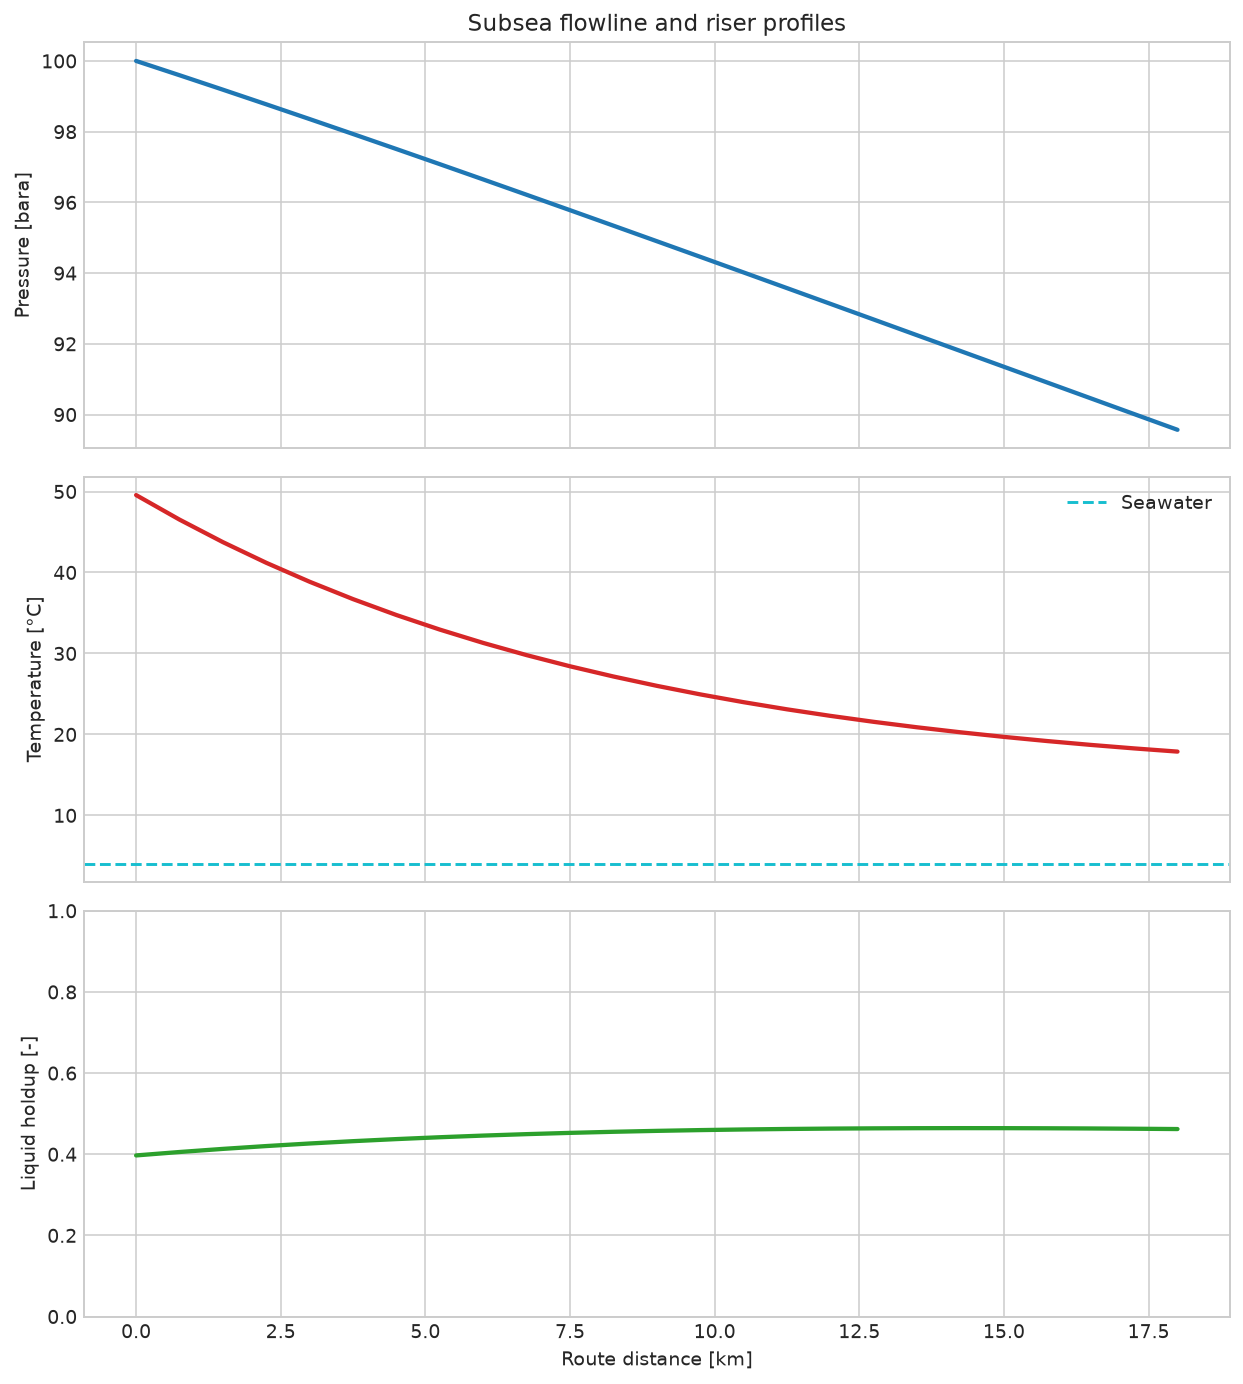

In [10]:
figure, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].plot(distance_km, pressure_profile_bara, color="tab:blue", linewidth=2.2)
axes[0].set_ylabel("Pressure [bara]")
axes[0].set_title("Subsea flowline and riser profiles")

axes[1].plot(distance_km, temperature_profile_c, color="tab:red", linewidth=2.2)
axes[1].axhline(
    CASE["seawater_temperature_c"],
    color="tab:cyan",
    linestyle="--",
    label="Seawater",
)
axes[1].set_ylabel("Temperature [°C]")
axes[1].legend()

axes[2].plot(distance_km, liquid_holdup_profile, color="tab:green", linewidth=2.2)
axes[2].set_xlabel("Route distance [km]")
axes[2].set_ylabel("Liquid holdup [-]")
axes[2].set_ylim(0.0, 1.0)

figure.tight_layout()
plt.show()

## Host separator phase and mass balance

The three-phase separator performs an equilibrium split at arrival pressure and temperature. Its
overall steady mass balance is:

$$
\dot{m}_{\mathrm{feed}} =
\dot{m}_{\mathrm{gas}} +
\dot{m}_{\mathrm{oil}} +
\dot{m}_{\mathrm{water}}
$$

This ideal equilibrium split omits droplet-size distributions, residence time, internals,
entrainment, level control, and separator mechanical design.

In [11]:
separator = base_case["separator"]
separator_outputs = {
    "gas": separator.getGasOutStream(),
    "oil": separator.getOilOutStream(),
    "water": separator.getWaterOutStream(),
}

separator_rows = []
for phase_name, stream_object in separator_outputs.items():
    separator_rows.append(
        {
            "phase": phase_name,
            "mass flow [kg/h]": stream_object.getFlowRate("kg/hr"),
            "molar flow [mol/s]": stream_object.getFlowRate("mole/sec"),
            "density [kg/m³]": stream_object.getFluid().getDensity("kg/m3"),
        }
    )

separator_table = pd.DataFrame(separator_rows).set_index("phase")
separator_feed_kg_h = pipeline.getOutletStream().getFlowRate("kg/hr")
separator_product_kg_h = separator_table["mass flow [kg/h]"].sum()
separator_mass_residual_kg_h = separator_product_kg_h - separator_feed_kg_h

display(separator_table.round(6))
print(f"Separator mass residual: {separator_mass_residual_kg_h:.12e} kg/h")

Separator mass residual: 1.964508555830e-10 kg/h


,mass flow [kg/h],molar flow [mol/s],density [kg/m³]
phase,,,
gas,9542.395520,130.667078,98.887345
oil,10279.350817,62.633779,509.423751
water,178.253662,2.745757,1000.210269


## Independent component closure

For every component $j$, the molar balance is reconstructed independently from stream flow and
overall mole fraction:

$$
\dot{n}_{j,\mathrm{feed}} = \sum_k \dot{n}_{j,k}
$$

The products $k$ are gas, oil, and water. This check can detect a plausible total mass balance
that hides a composition-transfer error.

In [12]:
def component_flow_mol_s(stream_object, component):
    thermodynamic_system = stream_object.getFluid()
    total_flow_mol_s = stream_object.getFlowRate("mole/sec")
    mole_fraction = thermodynamic_system.getComponent(component).getz()
    return total_flow_mol_s * mole_fraction


component_rows = []
product_streams = list(separator_outputs.values())

for component in COMPONENTS:
    feed_flow_mol_s = sum(
        component_flow_mol_s(feed, component)
        for feed in base_case["feeds"]
    )
    product_flow_mol_s = sum(
        component_flow_mol_s(product, component)
        for product in product_streams
    )
    component_rows.append(
        {
            "component": component,
            "feed [mol/s]": feed_flow_mol_s,
            "products [mol/s]": product_flow_mol_s,
            "residual [mol/s]": product_flow_mol_s - feed_flow_mol_s,
        }
    )

component_balance_table = pd.DataFrame(component_rows).set_index("component")
maximum_component_residual_mol_s = component_balance_table[
    "residual [mol/s]"
].abs().max()

display(component_balance_table.round(12))
print(
    "Maximum component residual: "
    f"{maximum_component_residual_mol_s:.12e} mol/s"
)

Maximum component residual: 9.947598300641e-13 mol/s


,feed [mol/s],products [mol/s],residual [mol/s]
component,,,
nitrogen,1.960466,1.960466,-0.000000e+00
CO2,4.336400,4.336400,-0.000000e+00
methane,130.585151,130.585151,-1.000000e-12
ethane,16.514664,16.514664,0.000000e+00
propane,13.009199,13.009199,0.000000e+00
i-butane,3.356167,3.356167,0.000000e+00
n-butane,5.732100,5.732100,0.000000e+00
i-pentane,2.375934,2.375934,0.000000e+00
n-pentane,2.375934,2.375934,0.000000e+00


## External-pressure and arrival-pressure screening

At water depth $z$, the approximate external absolute pressure is:

$$
P_{\mathrm{external}} = P_{\mathrm{atm}} + \rho_{\mathrm{sw}}gz
$$

Here seawater density $\rho_{\mathrm{sw}}$ is 1025 kg/m³, $g$ is 9.80665 m/s², and $z$ is m.
The internal-minus-external differential is not a wall-thickness result: installation, shutdown,
depressurization, collapse, buckling, corrosion allowance, temperature, and code factors require
a dedicated mechanical assessment. Arrival pressure is also compared with a 75 bara illustrative
host requirement.

In [13]:
SEAWATER_DENSITY_KG_PER_M3 = 1025.0
GRAVITY_M_PER_S2 = 9.80665
ATMOSPHERIC_PRESSURE_BARA = 1.01325

external_pressure_bar = (
    SEAWATER_DENSITY_KG_PER_M3
    * GRAVITY_M_PER_S2
    * CASE["maximum_water_depth_m"]
    / 1.0e5
)
external_pressure_bara = ATMOSPHERIC_PRESSURE_BARA + external_pressure_bar
manifold_pressure_bara = base_case["manifold"].getOutletStream().getPressure(
    "bara"
)
arrival_pressure_bara = pipeline.getOutletStream().getPressure("bara")
internal_external_differential_bar = (
    manifold_pressure_bara - external_pressure_bara
)
arrival_pressure_margin_bar = (
    arrival_pressure_bara - CASE["separator_minimum_pressure_bara"]
)

pressure_screen = pd.DataFrame(
    {
        "quantity": [
            "External absolute pressure at maximum depth",
            "Internal pressure at manifold",
            "Internal minus external pressure",
            "Host arrival pressure",
            "Arrival margin above illustrative requirement",
        ],
        "value [bar]": [
            external_pressure_bara,
            manifold_pressure_bara,
            internal_external_differential_bar,
            arrival_pressure_bara,
            arrival_pressure_margin_bar,
        ],
    }
).set_index("quantity")
display(pressure_screen.round(6))

,value [bar]
quantity,
External absolute pressure at maximum depth,36.194607
Internal pressure at manifold,100.000000
Internal minus external pressure,63.805393
Host arrival pressure,89.569058
Arrival margin above illustrative requirement,14.569058


## Choke-pressure sensitivity

The tree-choke set point is often an operating variable. Higher downstream choke pressure preserves
more pressure for transport, but the wells must be able to deliver against that backpressure. This
study varies only the common choke pressure; it does not include an inflow-performance relation or
closed-loop production control.

,choke pressure [bara],arrival pressure [bara],arrival temperature [°C]
0,85.0,75.461092,17.384713
1,90.0,80.154501,17.551385
2,95.0,84.856689,17.714740
3,100.0,89.569058,17.875162
4,105.0,94.292981,18.032868


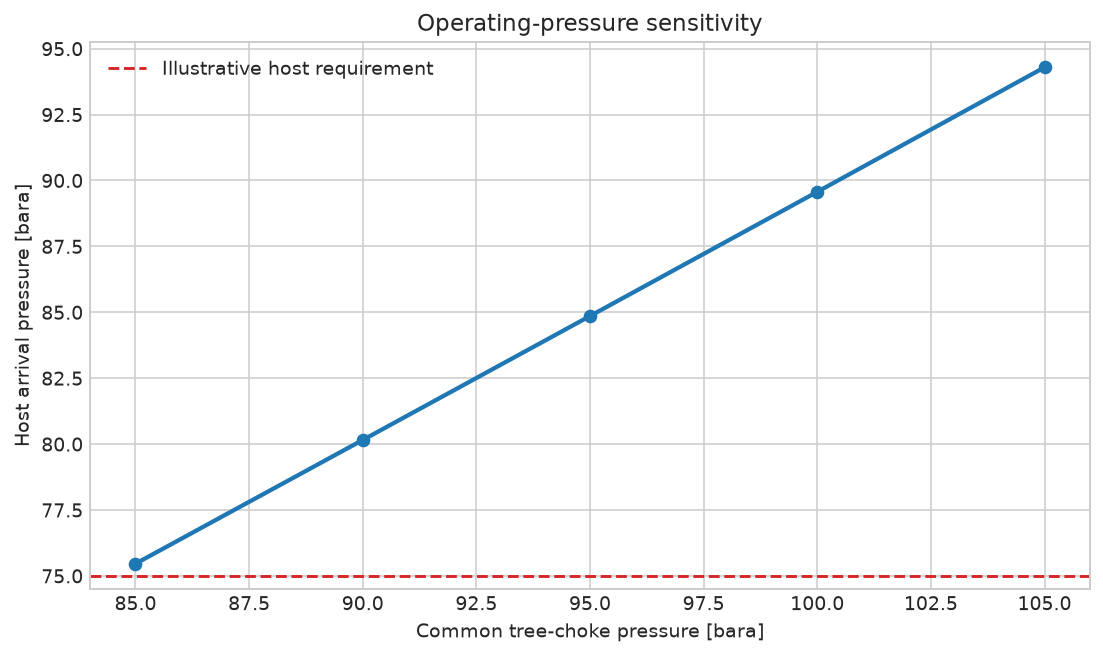

In [14]:
choke_pressures_bara = np.arange(85.0, 106.0, 5.0)
choke_rows = []

for choke_pressure_bara in choke_pressures_bara:
    result = simulate_subsea_system(
        choke_pressure_bara=float(choke_pressure_bara),
    )
    outlet_stream = result["pipeline"].getOutletStream()
    choke_rows.append(
        {
            "choke pressure [bara]": choke_pressure_bara,
            "arrival pressure [bara]": outlet_stream.getPressure("bara"),
            "arrival temperature [°C]": outlet_stream.getTemperature("C"),
        }
    )

choke_study = pd.DataFrame(choke_rows)
display(choke_study.round(6))

figure, axis = plt.subplots(figsize=(8, 4.8))
axis.plot(
    choke_study["choke pressure [bara]"],
    choke_study["arrival pressure [bara]"],
    marker="o",
    linewidth=2.2,
)
axis.axhline(
    CASE["separator_minimum_pressure_bara"],
    color="tab:red",
    linestyle="--",
    label="Illustrative host requirement",
)
axis.set_xlabel("Common tree-choke pressure [bara]")
axis.set_ylabel("Host arrival pressure [bara]")
axis.set_title("Operating-pressure sensitivity")
axis.legend()
figure.tight_layout()
plt.show()

## Thermal-design sensitivity

The overall heat-transfer coefficient combines internal convection, pipe wall, insulation,
external convection, and fouling into one screening input. Increasing $U$ cools the stream more
strongly. A detailed design would calculate the layer resistances, transient cooldown, hydrate and
wax margins, chemical demand, and restart strategy.

,U [W/(m² K)],arrival temperature [°C],outlet liquid holdup [-]
0,1.5,25.188488,0.436016
1,3.0,17.875162,0.462048
2,4.5,15.514727,0.470575
3,6.0,14.784270,0.472944


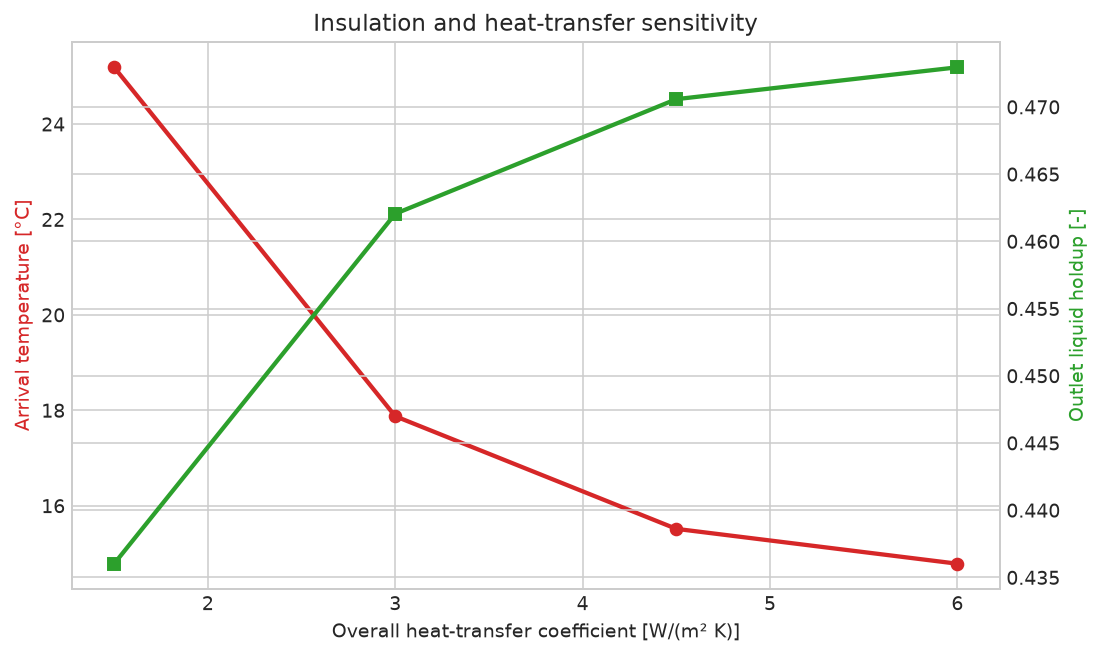

In [15]:
heat_transfer_values = np.asarray([1.5, 3.0, 4.5, 6.0])
thermal_rows = []

for heat_transfer_value in heat_transfer_values:
    result = simulate_subsea_system(
        heat_transfer_w_per_m2_k=float(heat_transfer_value),
    )
    outlet_stream = result["pipeline"].getOutletStream()
    holdup_values = np.asarray(
        list(result["pipeline"].getLiquidHoldupProfile()),
        dtype=float,
    )
    thermal_rows.append(
        {
            "U [W/(m² K)]": heat_transfer_value,
            "arrival temperature [°C]": outlet_stream.getTemperature("C"),
            "outlet liquid holdup [-]": holdup_values[-1],
        }
    )

thermal_study = pd.DataFrame(thermal_rows)
display(thermal_study.round(6))

figure, left_axis = plt.subplots(figsize=(8, 4.8))
right_axis = left_axis.twinx()
left_axis.plot(
    thermal_study["U [W/(m² K)]"],
    thermal_study["arrival temperature [°C]"],
    color="tab:red",
    marker="o",
    linewidth=2.2,
)
right_axis.plot(
    thermal_study["U [W/(m² K)]"],
    thermal_study["outlet liquid holdup [-]"],
    color="tab:green",
    marker="s",
    linewidth=2.2,
)
left_axis.set_xlabel("Overall heat-transfer coefficient [W/(m² K)]")
left_axis.set_ylabel("Arrival temperature [°C]", color="tab:red")
right_axis.set_ylabel("Outlet liquid holdup [-]", color="tab:green")
left_axis.set_title("Insulation and heat-transfer sensitivity")
figure.tight_layout()
plt.show()

## Throughput sensitivity and coupled multiphase behavior

Rate is varied from 60% to 140% of the base well rates with composition and wellhead conditions
fixed. Higher rate reduces residence time and therefore preserves more heat. In an inclined
multiphase line, pressure drop need not vary monotonically with rate because liquid holdup and the
hydrostatic term change together; that coupling is a useful warning against single-phase intuition.

,rate factor [-],total rate [kg/h],arrival pressure [bara],arrival temperature [°C],outlet liquid holdup [-]
0,0.6,12000.0,88.897510,15.131927,0.531192
1,0.8,16000.0,89.316752,16.350448,0.494322
2,1.0,20000.0,89.569058,17.875162,0.462048
3,1.2,24000.0,89.699013,19.482025,0.433263
4,1.4,28000.0,89.882245,21.073083,0.407958


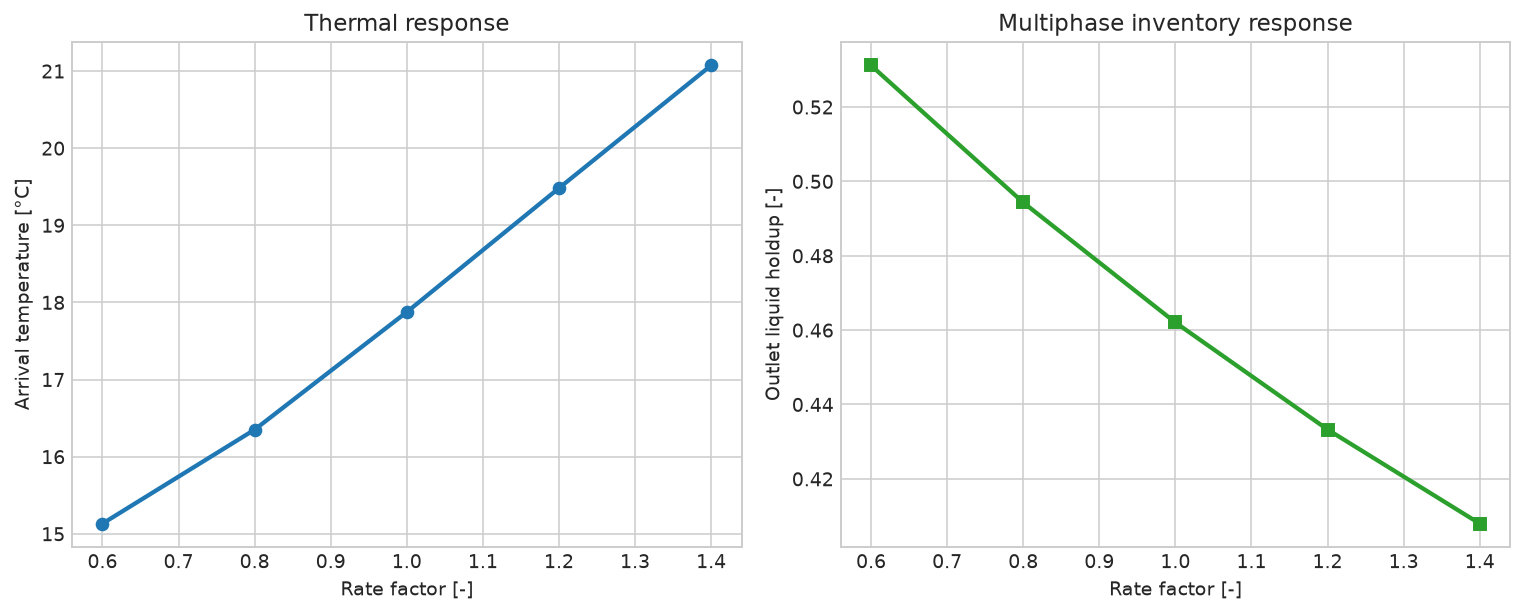

In [16]:
rate_factors = np.asarray([0.6, 0.8, 1.0, 1.2, 1.4])
rate_rows = []

for rate_factor in rate_factors:
    result = simulate_subsea_system(rate_factor=float(rate_factor))
    outlet_stream = result["pipeline"].getOutletStream()
    holdup_values = np.asarray(
        list(result["pipeline"].getLiquidHoldupProfile()),
        dtype=float,
    )
    rate_rows.append(
        {
            "rate factor [-]": rate_factor,
            "total rate [kg/h]": outlet_stream.getFlowRate("kg/hr"),
            "arrival pressure [bara]": outlet_stream.getPressure("bara"),
            "arrival temperature [°C]": outlet_stream.getTemperature("C"),
            "outlet liquid holdup [-]": holdup_values[-1],
        }
    )

rate_study = pd.DataFrame(rate_rows)
display(rate_study.round(6))

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(
    rate_study["rate factor [-]"],
    rate_study["arrival temperature [°C]"],
    marker="o",
    linewidth=2.2,
)
axes[0].set_xlabel("Rate factor [-]")
axes[0].set_ylabel("Arrival temperature [°C]")
axes[0].set_title("Thermal response")

axes[1].plot(
    rate_study["rate factor [-]"],
    rate_study["outlet liquid holdup [-]"],
    marker="s",
    color="tab:green",
    linewidth=2.2,
)
axes[1].set_xlabel("Rate factor [-]")
axes[1].set_ylabel("Outlet liquid holdup [-]")
axes[1].set_title("Multiphase inventory response")

figure.tight_layout()
plt.show()

## Numerical and physical validation

The acceptance checks cover input normalization, finite results, pressure ordering, energy closure,
mass and component conservation, bounded phase quantities, profile continuity, arrival margin, and
expected sensitivity trends. Trend checks are applied only where the physical expectation is
unambiguous for this frozen-input study.

In [17]:
check_results = {}

check_results["well compositions normalized"] = all(
    math.isclose(
        float(normalized_composition(specification).sum()),
        1.0,
        abs_tol=1.0e-12,
    )
    for specification in WELL_SPECIFICATIONS
)
check_results["all base outputs finite"] = bool(
    np.isfinite(pressure_profile_bara).all()
    and np.isfinite(temperature_profile_c).all()
    and np.isfinite(liquid_holdup_profile).all()
)
check_results["pressure profile decreases"] = bool(
    np.all(np.diff(pressure_profile_bara) < 0.0)
)
check_results["temperature remains above seawater"] = bool(
    temperature_profile_c.min() > CASE["seawater_temperature_c"]
)
check_results["liquid holdup bounded"] = bool(
    np.all((liquid_holdup_profile >= 0.0) & (liquid_holdup_profile <= 1.0))
)
check_results["profile lengths agree"] = (
    len(pressure_profile_bara)
    == len(temperature_profile_c)
    == len(liquid_holdup_profile)
    == len(flow_regimes)
)
check_results["pipeline inlet pressure is choke target"] = math.isclose(
    pressure_profile_bara[0],
    CASE["tree_choke_pressure_bara"],
    abs_tol=1.0e-9,
)
check_results["arrival pressure exceeds host requirement"] = (
    arrival_pressure_margin_bar > 0.0
)
check_results["internal pressure exceeds external pressure"] = (
    internal_external_differential_bar > 0.0
)
check_results["separator mass closes"] = (
    abs(separator_mass_residual_kg_h) < 1.0e-6
)
check_results["separator component balances close"] = (
    maximum_component_residual_mol_s < 1.0e-9
)
check_results["manifold mass closes"] = math.isclose(
    base_case["manifold"].getOutletStream().getFlowRate("kg/hr"),
    sum(feed.getFlowRate("kg/hr") for feed in base_case["feeds"]),
    rel_tol=1.0e-12,
)
check_results["manifold enthalpy closes"] = (
    abs(manifold_enthalpy_residual_j) < 1.0e-2
)
check_results["Well A choke is isenthalpic"] = (
    abs(energy_table.iloc[0]["residual [J/kg]"]) < 1.0e-2
)
check_results["Well B choke is isenthalpic"] = (
    abs(energy_table.iloc[1]["residual [J/kg]"]) < 1.0e-2
)
check_results["all separator products nonnegative"] = bool(
    (separator_table["mass flow [kg/h]"] >= 0.0).all()
)
check_results["separator products recover feed"] = math.isclose(
    separator_product_kg_h,
    separator_feed_kg_h,
    rel_tol=1.0e-12,
)
check_results["choke pressure study finite"] = bool(
    np.isfinite(choke_study.select_dtypes(include=[float, int])).all().all()
)
check_results["higher choke target raises arrival pressure"] = bool(
    np.all(np.diff(choke_study["arrival pressure [bara]"]) > 0.0)
)
check_results["thermal study finite"] = bool(
    np.isfinite(thermal_study.select_dtypes(include=[float, int])).all().all()
)
check_results["higher U lowers arrival temperature"] = bool(
    np.all(np.diff(thermal_study["arrival temperature [°C]"]) < 0.0)
)
check_results["rate study finite"] = bool(
    np.isfinite(rate_study.select_dtypes(include=[float, int])).all().all()
)
check_results["higher rate preserves heat"] = bool(
    np.all(np.diff(rate_study["arrival temperature [°C]"]) > 0.0)
)
check_results["all cases retain positive pressure"] = bool(
    (choke_study["arrival pressure [bara]"] > 0.0).all()
    and (rate_study["arrival pressure [bara]"] > 0.0).all()
)
check_results["base route has all increments"] = len(distance_km) == 25

failed_checks = [
    name
    for name, passed in check_results.items()
    if not passed
]
assert not failed_checks, f"Failed checks: {failed_checks}"

print(f"All {len(check_results)} engineering checks passed.")
for check_name in check_results:
    print(f"PASS | {check_name}")

All 25 engineering checks passed.
PASS | well compositions normalized
PASS | all base outputs finite
PASS | pressure profile decreases
PASS | temperature remains above seawater
PASS | liquid holdup bounded
PASS | profile lengths agree
PASS | pipeline inlet pressure is choke target
PASS | arrival pressure exceeds host requirement
PASS | internal pressure exceeds external pressure
PASS | separator mass closes
PASS | separator component balances close
PASS | manifold mass closes
PASS | manifold enthalpy closes
PASS | Well A choke is isenthalpic
PASS | Well B choke is isenthalpic
PASS | all separator products nonnegative
PASS | separator products recover feed
PASS | choke pressure study finite
PASS | higher choke target raises arrival pressure
PASS | thermal study finite
PASS | higher U lowers arrival temperature
PASS | rate study finite
PASS | higher rate preserves heat
PASS | all cases retain positive pressure
PASS | base route has all increments


## Engineering interpretation

The two wells deliver 20,000 kg/h after isenthalpic pressure letdown. In the base case, the route
arrives at the host with positive pressure margin, substantial cooling, and three equilibrium
phases. The water outlet is small but nonzero, while most liquid leaves as hydrocarbon condensate.

The sensitivities show three distinct levers:

- choke pressure directly changes transport pressure and host margin;
- insulation performance changes arrival temperature and liquid inventory;
- throughput changes residence time, thermal response, and multiphase holdup together.

These outputs support early architecture and operability discussions. They are not vendor sizing or
design-code acceptance evidence.

In [18]:
final_summary = pd.DataFrame(
    {
        "quantity": [
            "Total well rate",
            "Host arrival pressure",
            "Host arrival temperature",
            "Pipeline pressure drop",
            "Outlet liquid holdup",
            "Gas product rate",
            "Oil product rate",
            "Water product rate",
            "Arrival pressure margin",
            "Maximum component residual",
        ],
        "value": [
            separator_feed_kg_h,
            arrival_pressure_bara,
            pipeline.getOutletStream().getTemperature("C"),
            pressure_profile_bara[0] - pressure_profile_bara[-1],
            liquid_holdup_profile[-1],
            separator_table.loc["gas", "mass flow [kg/h]"],
            separator_table.loc["oil", "mass flow [kg/h]"],
            separator_table.loc["water", "mass flow [kg/h]"],
            arrival_pressure_margin_bar,
            maximum_component_residual_mol_s,
        ],
        "unit": [
            "kg/h",
            "bara",
            "°C",
            "bar",
            "-",
            "kg/h",
            "kg/h",
            "kg/h",
            "bar",
            "mol/s",
        ],
    }
).set_index("quantity")

display(final_summary.round(9))

,value,unit
quantity,,
Total well rate,20000.000000,kg/h
Host arrival pressure,89.569058,bara
Host arrival temperature,17.875162,°C
Pipeline pressure drop,10.430942,bar
Outlet liquid holdup,0.462048,-
Gas product rate,9542.395520,kg/h
Oil product rate,10279.350817,kg/h
Water product rate,178.253662,kg/h
Arrival pressure margin,14.569058,bar


## Limitations and applicability

- Beggs-Brill is an empirical steady-state correlation. Confirm its diameter, inclination, fluid,
  and flow-regime applicability before design use.
- The combined route uses one equivalent length, diameter, elevation, roughness, ambient
  temperature, and heat-transfer coefficient. A real route needs segment-by-segment geometry.
- No dynamic slugging, severe-slugging stability, cooldown, restart, terrain, erosion, sand,
  corrosion, scale, wax, hydrate, or chemical-injection model is included.
- Well inflow and reservoir deliverability are fixed; choke backpressure does not feed back to rate.
- The separator is an equilibrium split without efficiency or mechanical-design constraints.
- External-pressure screening is not a collapse or wall-thickness calculation.
- The synthetic composition and equipment conditions are educational and must not be used as a
  field design basis.

## Current NeqSim documentation used

- [Process simulation package](https://equinor.github.io/neqsim/process/README.html)
- [Throttling valves and production chokes](https://github.com/equinor/neqsim/blob/master/docs/process/equipment/valves.md)
- [Mixers and splitters](https://github.com/equinor/neqsim/blob/master/docs/process/equipment/mixers_splitters.md)
- [Beggs-Brill pipeline model](https://github.com/equinor/neqsim/blob/master/docs/process/PipeBeggsAndBrills.md)
- [Pipeline simulation guide](https://equinor.github.io/neqsim/process/equipment/pipeline_simulation)
- [Separator equipment](https://github.com/equinor/neqsim/blob/master/docs/process/equipment/separators.md)
- [Thermodynamic operations and flash calculations](https://equinor.github.io/neqsim/thermodynamicoperations/README.html)

## Practical next steps and exercises

1. Replace the equivalent route with separate horizontal flowline and riser segments.
2. Add an inflow-performance relation and solve well rate against choke and host pressure.
3. Compare `cpa-srk` with `pr` and explain changes in water and condensate disposition.
4. Add hydrate, wax, cooldown, and restart analyses before specifying insulation or chemicals.
5. Connect a separator-sizing and slug-catcher study to the host-arrival stream.
6. Evaluate shutdown/depressurization differential pressure against a recognized pipeline code and
   documented material data.